# Visualisasi Embedding Similarity

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "cheap internet package",
    "cheap internet cost",
    "How to subscribe to affordable internet packages",
    "learn basic machine learning"
]

embeddings = model.encode(sentences)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 467.47it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dari hasil proses tersebut, mungkin awalnya akan terdapat adanya warning dan kita di minta untuk mengatur HF_TOKEN jika ingin lebih cepat dalam download model. Cara untuk set HF_TOKEN ini tidak wajib namun sangat disarankan. Untuk mendapatkan token huggingface, silahkan kunjungi panduan berikut https://huggingface.co/docs/hub/security-tokens.

In [ ]:
# from huggingface_hub import login
# login('hf_token_anda')

Selanjutnya, kita akan coba mengecek model yang telah berhasil di download.

In [ ]:
print(model)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [ ]:
import os
# from huggingface_hub import hf_hub_download

cache_dir = os.path.expanduser("~/.cache/huggingface/hub")
print(os.listdir(cache_dir))


['.locks', 'models--sentence-transformers--all-MiniLM-L6-v2']


Model yang terdownload ada di folder `~/.cache/huggingface/hub`

In [ ]:
print(embeddings.shape)

(4, 384)


Keterangan:
- 4 adalah jumlah baris atau dalam hal ini ada 4 embedding yang dihasilkan dari 4 kalimat.
- Model all-MiniLM-L6-v2 menghasilkan vektor berdimensi 384

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)


[[1.0000002  0.80940306 0.74130166 0.05794605]
 [0.80940306 1.0000001  0.60747206 0.03857384]
 [0.74130166 0.60747206 0.99999994 0.0706685 ]
 [0.05794605 0.03857384 0.0706685  1.0000002 ]]


Perhatikan pada `baris 0 atau kalimat pertama (cheap internet package`, terdapat nilai kemiripan `[1.0000002  0.80940306 0.66102654 0.05794605]`.
Artinya kalimat tersebut mirip dengan:
- dirinya sendiri (kalimat 1) → 1
- kalimat 2 → 0.8094028
- kalimat 3 → 0.5629885
- kalimat 4 → 0.05794607



Selanjutnya kita akan buat visualisasi 2D dengan PCA.

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
print(f"Original embedding dimensions: {embeddings.shape[1]}")
print(f"Reduced embedding dimensions: {reduced.shape[1]}")
print(f"\nVariance explained by these 2 dimensions: {pca.explained_variance_ratio_.sum():.2%}")

Original embedding dimensions: 384
Reduced embedding dimensions: 2

Variance explained by these 2 dimensions: 91.23%


`Variance explained` memberi tahu kita seberapa besar variasi dalam data asli yang dipertahankan dalam 2 dimensi ini

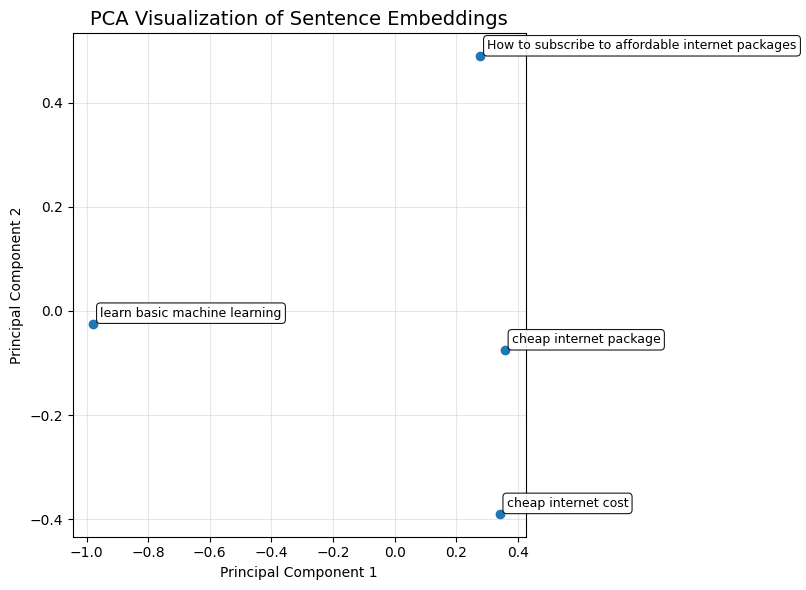

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(reduced[:, 0], reduced[:, 1])

for i, txt in enumerate(sentences):
    plt.annotate(
        txt,
        (reduced[i, 0], reduced[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",      # background color
            ec="black",      # edge color
            lw=0.8,
            alpha=0.9
        )
    )

plt.title("PCA Visualization of Sentence Embeddings", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Dari gambar di atas, dapat dilihat bahwa kalimat `cheap internet package` dengan kalimat `cheap internet cost` berdekatan, namun kalimat `how to register an internet package` kelihatan agak berjauhan. Kejadian ini bisa diakibatkan karena PCA menghilangkan bebeberapa informasi yang ada, sehingga jika di visualisasikan secara 2D, kemiripan antar kalimat tersebut terkadang kurang terlihat.

Kita juga dapat menggunakan network untuk melihat kemiripan antar kalimat.

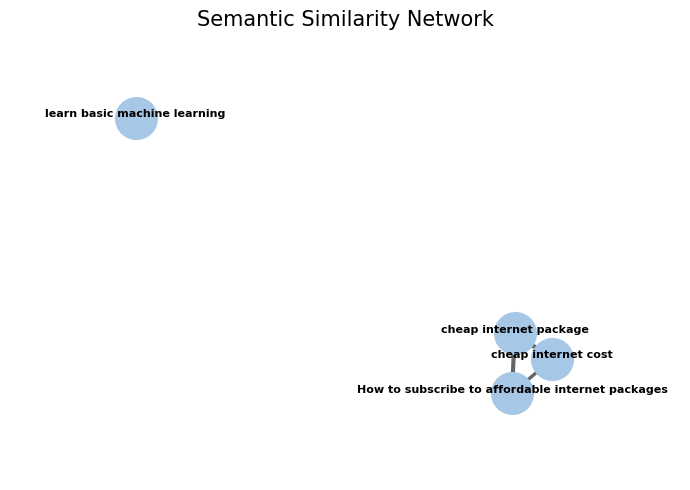

In [ ]:
import networkx as nx

G = nx.Graph()

for s in sentences:
    G.add_node(s)

threshold = 0.4
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = similarity_matrix[i][j]
        if sim > threshold:
            G.add_edge(sentences[i], sentences[j], weight=sim)

# Atur  layout lebih luas
pos = nx.spring_layout(G, k=1.5, iterations=200, seed=42)

plt.figure(figsize=(7,5))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=900,
    node_color="#A7C7E7"
)

# Edges
edges = G.edges(data=True)
weights = [d['weight']*4 for (_,_,d) in edges]

nx.draw_networkx_edges(
    G, pos,
    width=weights,
    alpha=0.6
)

# Geser label
label_pos = {k: (v[0], v[1] + 0.01) for k, v in pos.items()}

nx.draw_networkx_labels(
    G, label_pos,
    font_size=8,
    font_weight='bold'
)

plt.title("Semantic Similarity Network", fontsize=15)

plt.margins(0.3)      # <-- penting supaya tidak kepotong
plt.axis("off")
plt.tight_layout()
plt.show()

Pada gambar di atas, kalimat 1,2 dan 3 tampak saling berdekatan dan terhubung, ini mengindikasikan kalimat tersebut memiliki kemiripan yang tinggi. Sedangkan kalimat 4 tidak terhubung dengan kalimat lainnya yang menandakan bahwa kalimat tersebut tidak mirip.

# Keyword Search vs Semantic Search

`Keyword Search` adalah teknik untuk mencari kata yang memiliki kecocokan kata persis (exact match) dan tidak memahami makna, sedangkan `Semantic Search` adalah teknik untuk mencari kata yang memiliki kecocokan kata dan juga memiliki kemiripan maknanya.

Misalkan kita mau mencari keyword umroh murah, maka keyword search akan menampilkan kalimat yang mengandung kata umroh dan murah, sedangkan semantic search akan menampilkan kalimat yang memiliki kemiripan dengan kata umroh dan murah.

In [ ]:
documents = [
    "cheap internet package",
    "cheap internet cost",
    "How to subscribe to affordable internet packages",
    "learn basic machine learning"
]

## Keyword Search

Berikut akan kita lakukan contoh sederhana dari keyword search

In [ ]:
# keyword search dengan hardcode keyword
query = "cheap internet subscription"
keyword = "cheap internet"

results = [doc for doc in documents if keyword in doc.lower()]

print("Search Result:", results)

Search Result: ['cheap internet package', 'cheap internet cost']


In [ ]:
# improved keyword search dengan beberapa kata di query.
query = "cheap internet subscription"

query_words = query.lower().split()

results = [
    doc for doc in documents
    if any(word in doc.lower() for word in query_words)
]

print("Search Result:", results)

Search Result: ['cheap internet package', 'cheap internet cost', 'How to subscribe to affordable internet packages']


### TF-IDF

Selanjutnya, kita dapat mencoba menggunakan teknik lain, yaitu TF-IDF.

- TF (Term Frequency) → seberapa sering kata muncul di dokumen
- IDF (Inverse Document Frequency) → seberapa jarang kata itu di seluruh corpus

Inti dari teknik ini adalah kata yang sering muncul di dokumen tertentu tapi jarang muncul di dokumen lain akan dianggap penting.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Ubah ke DataFrame supaya mudah dibaca
df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

display(df)

,affordable,basic,cheap,cost,how,internet,learn,learning,machine,package,packages,subscribe,to
0,0.000000,0.0,0.553492,0.000000,0.000000,0.448100,0.0,0.0,0.0,0.702035,0.000000,0.000000,0.000000
1,0.000000,0.0,0.553492,0.702035,0.000000,0.448100,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,0.344881,0.0,0.000000,0.000000,0.344881,0.220133,0.0,0.0,0.0,0.000000,0.344881,0.344881,0.689761
3,0.000000,0.5,0.000000,0.000000,0.000000,0.000000,0.5,0.5,0.5,0.000000,0.000000,0.000000,0.000000


Dari tabel diatas, kita dapat mengetahui kata yang sering muncul di setiap kalimat. Nilai 0 berarti kata tersebut tidak muncul di kalimat tersebut.

Selanjutnya kita dapat menggunakan cosine similarity untuk mengetahui kemiripan antara kalimat atau dokumen.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

query = ["cheap internet subscription"] # harus dalam bentuk list karena vectorizer.transform() mengharapkan iterable

query_vec = vectorizer.transform(query)

similarities = cosine_similarity(query_vec, tfidf_matrix)

for doc, score in zip(documents, similarities[0]):
    print(f"{doc} -> {score:.4f}")

cheap internet package -> 0.7121
cheap internet cost -> 0.7121
How to subscribe to affordable internet packages -> 0.1385
learn basic machine learning -> 0.0000


Dari output diatas, kita dapat mengetahui bahwa kalimat `How to subscribe to affordable internet packages` akan dianggap tidak terlalu mirip atau memiliki kemiripan yang kecil karena tidak mengandung keyword yang serupa walaupun dari sisi makna memiliki kemiripan dengan query yang diberikan.

### BM25

Selanjutnya kita akan coba dengan BM25.


| Aspek | BM25 (Okapi) | BM25L | BM25+ |
| :--- | :--- | :--- | :--- |
| **Konsep Dasar** | Algoritma standar; menjadi titik acuan utama pencarian berbasis teks. | Memodifikasi perhitungan **Term Frequency (TF)** agar lebih stabil pada dokumen panjang. | Menambahkan **konstanta $\delta$ (delta)** agar dokumen panjang tidak kehilangan relevansi. |
| **Normalisasi Panjang** | Sangat agresif; cenderung menghukum dokumen yang sangat panjang. | Paling stabil dan halus dalam menangani variasi panjang dokumen yang ekstrem. | Lebih adil daripada Okapi; memastikan dokumen panjang tetap mendapat skor layak. |
| **Penalti Dokumen Panjang** | **Tinggi** (Berisiko *over-penalization* atau skor terlalu kecil). | **Rendah** (Penalti disesuaikan secara logis terhadap kepadatan kata). | **Rendah** (Dibatasi oleh nilai batas bawah $\delta$). |
| **Kelebihan Utama** | Sederhana dan efektif untuk dokumen dengan panjang seragam. | Sangat akurat untuk koleksi dokumen yang panjangnya sangat bervariasi. | Menjamin setiap kata kunci yang cocok selalu memberikan kontribusi skor positif. |
| **Parameter Kunci** | $k1, b$ | $k1, b, \delta$ (Default $\delta \approx 0.5$) | $k1, b, \delta$ (Default $\delta \approx 1.0$) |




Keterangan Parameter:
- k1: Mengatur pengaruh term frequency (TF). Semakin besar nilai k1, maka frekuensi kata makin berpengaruh.
- b: Mengatur normalisasi panjang dokumen.
    - b = 1 → normalisasi penuh (dokumen panjang tidak diuntungkan)
    - b = 0 → tidak mempertimbangkan panjang dokumen
- delta:  Menetapkan nilai batas bawah (lower bound) untuk kontribusi skor setiap kata kunci yang cocok. Ini mencegah dokumen yang sangat panjang mendapatkan skor mendekati nol hanya karena faktor pembagi (normalisasi panjang) yang terlalu besar.
    - BM25L → nilai defaultnya 0.5
    - BM25+ → nilai defaultnya 1.


Jika nilai `delta` terlalu besar:
- Dokumen yang sangat panjang bisa naik ke peringkat atas secara tidak wajar.
- Dokumen pendek yang sangat padat dan relevan (to-the-point) mungkin kalah bersaing karena keunggulan kepadatan kata mereka "tertutup" oleh nilai konstan yang diberikan kepada semua dokumen.

In [ ]:
from rank_bm25 import BM25Okapi, BM25L, BM25Plus


# Tokenisasi
tokenized_docs = [doc.lower().split() for doc in documents]

# Query
query = "cheap internet subscription"
tokenized_query = query.lower().split()

# Inisialisasi masing-masing model
bm25 = BM25Okapi(tokenized_docs)
bm25l = BM25L(tokenized_docs)
bm25plus = BM25Plus(tokenized_docs)

# Hitung skor
scores_bm25 = bm25.get_scores(tokenized_query)
scores_bm25l = bm25l.get_scores(tokenized_query)
scores_bm25plus = bm25plus.get_scores(tokenized_query)

print("=== BM25 ===")
for doc, score in zip(documents, scores_bm25):
    print(f"{doc} -> {score:.4f}")

print("\n=== BM25L ===")
for doc, score in zip(documents, scores_bm25l):
    print(f"{doc} -> {score:.4f}")

print("\n=== BM25+ ===")
for doc, score in zip(documents, scores_bm25plus):
    print(f"{doc} -> {score:.4f}")

=== BM25 ===
cheap internet package -> 0.1878
cheap internet cost -> 0.1878
How to subscribe to affordable internet packages -> 0.1262
learn basic machine learning -> 0.0000

=== BM25L ===
cheap internet package -> 1.4254
cheap internet cost -> 1.4254
How to subscribe to affordable internet packages -> 0.3914
learn basic machine learning -> 0.0000

=== BM25+ ===
cheap internet package -> 3.0719
cheap internet cost -> 3.0719
How to subscribe to affordable internet packages -> 1.8227
learn basic machine learning -> 1.4271


Dapat dilihat dari output diatas bahwa BM25+ cenderung memberikan skor lebih tinggi karena menambahkan konstanta delta, sehingga dokumen yang relevan tetap mendapatkan skor dasar dan tidak terlalu dihukum akibat panjang dokumen atau frekuensi kata yang rendah.

## Semantic Search

In [ ]:
# menggunakan model transformer dan cosine similarity
model = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = model.encode(documents)
query = "cheap internet subscription"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, doc_embeddings)

print(similarities)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 488.39it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[0.76051366 0.8009504  0.778207   0.1249823 ]]


In [ ]:
# Ambil array 1D yang ada di dalam array 2D
similarity_scores = similarities[0]

# Gabungkan dengan dokumen
for doc, score in zip(documents, similarity_scores):
    print(f"{doc}  ->  {score:.4f}")

cheap internet package  ->  0.7605
cheap internet cost  ->  0.8010
How to subscribe to affordable internet packages  ->  0.7782
learn basic machine learning  ->  0.1250


In [ ]:
# Kalau mau diurutkan (Ranking)
ranked = sorted(zip(documents, similarity_scores),
                key=lambda x: x[1],
                reverse=True)

print("\nRanking:")
for doc, score in ranked:
    print(f"{doc}  ->  {score:.4f}")


Ranking:
cheap internet cost  ->  0.8010
How to subscribe to affordable internet packages  ->  0.7782
cheap internet package  ->  0.7605
learn basic machine learning  ->  0.1250


Kita juga dapat menggunakan numpy untuk mengurutkan skor, kemudinan mengambil 3 dokumen teratas.

In [ ]:
import numpy as np
top_k=3 #ambil 3 teratas

top_idx = np.argsort(similarities[0])[::-1][:top_k]
top_docs = [documents[i] for i in top_idx]
print("\nTop 3 Documents:")
for doc in top_docs:
    print(doc)


Top 3 Documents:
cheap internet cost
How to subscribe to affordable internet packages
cheap internet package


Dengan Semantic Search, kalimat `How to subscribe to affordable internet packages` akan tetap memiliki skor yang cukup relevan karena dari sisi makna kata tersebut mengandung kemiripan dengan `cheap internet subscription`. Walaupun dari sisi keyword kurang cocok.

# Vector Database

Vector Database merupakan tempat untuk menyimpan kumpulan dokumen dan embeddingnya, sehingga dapat diakses dengan cepat dan efisien.

kita dapat dapat mencoba membuat vector database sederhana atau mini vector database (tanpa DB eksternal) untuk menyimpan dokumen dan embeddingnya seperti contoh berikut ini:

In [ ]:
vector_store = {
    "documents": documents,
    "embeddings": doc_embeddings
}

Kita akan gunakan model semantic search yang telah kita definisikan sebelumnya dan membuat fungsi untuk melakukan semantic search.

In [ ]:
def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, vector_store["embeddings"])
    top_idx = np.argsort(similarities[0])[::-1][:top_k]

    return [vector_store["documents"][i] for i in top_idx]

query="paket ibadah hemat"
semantic_search(query)

['cheap internet package', 'How to subscribe to affordable internet packages']

Selanjutnya kita akan mencoba menggunakan beberapa Vector Database seperti Pinecone dan ChromaDB.

## ChromaDB

In [ ]:
# !pip install "chromadb>=1.5.1"

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer

#  Load model embedding
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 352.13it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Selanjutnya kita akan mendefinisikan client. Untuk mendefinisikan ada 2 cara:
1. in-memory (RAM): Tidak ada folder database, dan data akan hilang saat notebook / Python mati
    ```python
    client = chromadb.Client()
    ```
2. Disk (Persistent): Data akan disimpan di folder tertentu.
    ```python
    import chromadb
    from chromadb.config import Settings

    client = chromadb.Client(
        Settings(
            persist_directory="./chroma_db",
            is_persistent=True
        )
    )```

In [ ]:
# # Buat client Chroma (in-memory atau RAM)
# client = chromadb.Client()

# # Buat collection
# collection = client.create_collection(name="my_docs")

In [ ]:
import chromadb
from chromadb.config import Settings

# simpan chromaDB ke disk di directory "chroma_db"
client = chromadb.Client(
    Settings(
        persist_directory="./chroma_db",
        is_persistent=True
    )
)

# Buat collection
create_collection = client.create_collection(name="my_docs")

Ketika membuat koleksi, kita dapat menambahkan metadata untuk mengatur jarak yang digunakan, apakah menggunakan `cosine`, `inner product` atau `Squared L2`. Default distance atau jarak yang digunakan adalah `L2`.


Misalkan ingin menggunakan `cosine` maka kita dapat menggunakan perintah berikut ini:
```python
collection = client.create_collection(
    name="my_docs",
    metadata={"hnsw:space": "cosine"}
)
```

Referensi: https://docs.trychroma.com/docs/collections/configure

In [ ]:
# client.delete_collection(name="my_docs")

In [ ]:
# Cek Collection yang ada
collections = client.list_collections()
print(collections)

[Collection(name=my_docs)]


In [ ]:
# cek collection berdasarkan nama
collection_name = "my_docs"
if collection_name in [c.name for c in client.list_collections()]:
    print("Collection sudah ada")

Collection sudah ada


Selanjutnya, Kita akan menggunakan collection yang sudah ada untuk menyimpan data.

In [ ]:
# jika collection sudah ada, kita bisa langsung ambil. jika belum ada, maka buat yang baru.
try:
    collection = client.get_collection("my_docs")
except:
    collection = client.create_collection("my_docs")

In [ ]:
# cek isi collection
data = collection.get()
print(data)

{'ids': [], 'embeddings': None, 'documents': [], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': []}


In [ ]:
# cek isi collection dan kasih limit
data = collection.get(limit=5)
print(data)

{'ids': [], 'embeddings': None, 'documents': [], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': []}


Isinya masih kosong, kita akan menambahkan data ke collection.

In [ ]:
documents = [
    "Cara daftar paket umroh murah",
    "Prosedur registrasi ibadah dengan harga terjangkau",
    "Cara daftar haji terjangkau",
    "Belajar Python untuk Data Science"
]

# buat embedding untuk dokumen dan jadikan list supaya bisa disimpan ke ChromaDB
embeddings = model.encode(documents).tolist()
# simpan ke ChromaDB
collection.add(
    documents=documents,
    embeddings=embeddings,
    ids=[str(i) for i in range(len(documents))],
    metadatas=[
        {"category": "umroh"},
        {"category": "umroh"},
        {"category": "haji"},
        {"category": "programming"}
    ]
)

Pada contoh diatas, kita telah menambahkan 4 dokumen ke collection dan juga menambahkan metadata category untuk setiap dokumen.

`Metadata` adalah informasi tambahan yang bisa ditambahkan ke dokumen. Informasi ini dapat berupa keyword ataupun pengkategorian dokumen. Misalkan pengkategorian dokumen menjadi umroh, haji, programming, dll.

In [ ]:
data = collection.get()
print(data)

{'ids': ['0', '1', '2', '3'], 'embeddings': None, 'documents': ['Cara daftar paket umroh murah', 'Prosedur registrasi ibadah dengan harga terjangkau', 'Cara daftar haji terjangkau', 'Belajar Python untuk Data Science'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'category': 'umroh'}, {'category': 'umroh'}, {'category': 'haji'}, {'category': 'programming'}]}


In [ ]:
display(data)

{'ids': ['0', '1', '2', '3'],
 'embeddings': None,
 'documents': ['Cara daftar paket umroh murah',
  'Prosedur registrasi ibadah dengan harga terjangkau',
  'Cara daftar haji terjangkau',
  'Belajar Python untuk Data Science'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'category': 'umroh'},
  {'category': 'umroh'},
  {'category': 'haji'},
  {'category': 'programming'}]}

Chroma tidak mengembalikan embeddings secara default, kita perlu menambahkan `include=["embeddings"]` jika ingin melihat embeddings

In [ ]:
data = collection.get(include=["documents", "embeddings", "metadatas"])
display(data)

{'ids': ['0', '1', '2', '3'],
 'embeddings': array([[-0.09345854,  0.07896772,  0.00378476, ...,  0.02725565,
         -0.00948653, -0.02750069],
        [ 0.00937278,  0.05039931, -0.09955561, ...,  0.05403472,
          0.0084849 , -0.04768511],
        [-0.06723957,  0.08850606, -0.0313442 , ...,  0.04108526,
          0.0193591 , -0.07980036],
        [-0.09599649,  0.00549821, -0.06329281, ..., -0.02683015,
         -0.0194859 , -0.0345783 ]], shape=(4, 384)),
 'documents': ['Cara daftar paket umroh murah',
  'Prosedur registrasi ibadah dengan harga terjangkau',
  'Cara daftar haji terjangkau',
  'Belajar Python untuk Data Science'],
 'uris': None,
 'included': ['documents', 'embeddings', 'metadatas'],
 'data': None,
 'metadatas': [{'category': 'umroh'},
  {'category': 'umroh'},
  {'category': 'haji'},
  {'category': 'programming'}]}

Selanjutnya kita akan mencoba melakukan pencarian berdasarkan query.

In [ ]:
# lakukan pencarian dengan query
query = "registrasi umroh murah"
# query juga harus di-embedding dulu supaya bisa dibandingkan dengan embedding dokumen yang sudah disimpan
query_embedding = model.encode([query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=4 # mirip dengan top_k
)

display(results)

{'ids': [['0', '1', '2', '3']],
 'embeddings': None,
 'documents': [['Cara daftar paket umroh murah',
   'Prosedur registrasi ibadah dengan harga terjangkau',
   'Cara daftar haji terjangkau',
   'Belajar Python untuk Data Science']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'category': 'umroh'},
   {'category': 'umroh'},
   {'category': 'haji'},
   {'category': 'programming'}]],
 'distances': [[0.6655105352401733,
   0.7511968016624451,
   1.1227238178253174,
   1.5673015117645264]]}

Selain itu, kita juga bisa menambahkan filter berdasarkan metadata. Misalkan kita hanya ingin menampilkan dokumen yang berkategori "umroh".

In [ ]:
results = collection.query(
    query_embeddings=query_embedding,
    n_results=4, # mirip dengan top_k
    where={"category": "umroh"}, # filter berdasarkan metadata category "umroh"
)

display(results)

{'ids': [['0', '1']],
 'embeddings': None,
 'documents': [['Cara daftar paket umroh murah',
   'Prosedur registrasi ibadah dengan harga terjangkau']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'category': 'umroh'}, {'category': 'umroh'}]],
 'distances': [[0.6655105352401733, 0.7511968016624451]]}

Chroma secara internal bekerja dengan algoritma pencarian jarak terdekat (Nearest Neighbor Search).
Pada hasil pencarian tersebut, kita dapat melihat terdapat nilai `distance` yaitu jarak antara embedding query dan embedding dokumen di ruang vektor. Di sini kita menggunakan `L2`.

- Semakin kecil distance → semakin mirip secara makna
- Semakin besar distance → semakin tidak mirip

Untuk melihat lebih detail nilai embedding, kita perlu menambahkan `include=["documents", "distances", "metadatas", "embeddings"]` agar kita dapat melihat embedding,

In [ ]:
results = collection.query(
    query_embeddings=query_embedding,
    n_results=3, #ambil 3 dokumen teratas
    include=["documents", "distances","metadatas","embeddings"] # tambahkan embedding
)

display(results)

{'ids': [['0', '1', '2']],
 'embeddings': [array([[-0.09345854,  0.07896772,  0.00378476, ...,  0.02725565,
          -0.00948653, -0.02750069],
         [ 0.00937278,  0.05039931, -0.09955561, ...,  0.05403472,
           0.0084849 , -0.04768511],
         [-0.06723957,  0.08850606, -0.0313442 , ...,  0.04108526,
           0.0193591 , -0.07980036]], shape=(3, 384))],
 'documents': [['Cara daftar paket umroh murah',
   'Prosedur registrasi ibadah dengan harga terjangkau',
   'Cara daftar haji terjangkau']],
 'uris': None,
 'included': ['documents', 'distances', 'metadatas', 'embeddings'],
 'data': None,
 'metadatas': [[{'category': 'umroh'},
   {'category': 'umroh'},
   {'category': 'haji'}]],
 'distances': [[0.6655105352401733, 0.7511968016624451, 1.1227238178253174]]}

Agar lebih rapih kita bisa fokuskan hanya dokumen dan distance-nya saja menggunakan looping.

In [ ]:
for doc, dist in zip(results["documents"][0], results["distances"][0]):
    print(f"{doc} -> Distance: {dist:.4f}")

Cara daftar paket umroh murah -> Distance: 0.6655
Prosedur registrasi ibadah dengan harga terjangkau -> Distance: 0.7512
Cara daftar haji terjangkau -> Distance: 1.1227


Jika ingin menghapus collection atau dokumen tertentu kita dapat menggunakan `collection.delete()`.

In [ ]:
# delete dokumen dengan id "2"
collection.delete(ids=["2"])

# cek isi collection setelah delete
collection.get()

{'ids': ['0', '1', '3'],
 'embeddings': None,
 'documents': ['Cara daftar paket umroh murah',
  'Prosedur registrasi ibadah dengan harga terjangkau',
  'Belajar Python untuk Data Science'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'category': 'umroh'},
  {'category': 'umroh'},
  {'category': 'programming'}]}

In [ ]:
# delete dokumen dengan metadata category "umroh"
collection.delete(where={"category": "umroh"})
collection.get()

{'ids': ['3'],
 'embeddings': None,
 'documents': ['Belajar Python untuk Data Science'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'category': 'programming'}]}

In [ ]:
# delete seluruh collection
client.delete_collection(name="my_docs")

## Pinecone


Sebelum membuat index di Pinecone, kita perlu melakukan inisialisasi terlebih dahulu untuk client dan model yang akan digunakan.

In [ ]:
# !pip install "pinecone>=8.1.0"

In [ ]:
from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer
import numpy as np

# Inisialisasi Pinecone client
PINECONE_API_KEY = "your_pinecone_api_key"
pc = Pinecone(api_key=PINECONE_API_KEY)
index_name='latihan-semantic-search' # nama index yang akan digunakan

# Inisialisasi model
model = SentenceTransformer('all-MiniLM-L6-v2')
model_dimension=384


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 410.67it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Penulisan API Key sebaiknya dilakukan di environment variable, misalnya di `.env` dengan nama `PINECONE_API_KEY`, kemudian diambil menggunakan perintah berikut:
```python
import os
from dotenv import load_dotenv

load_dotenv()

pinecone_api_key = os.getenv("PINECONE_API_KEY")
```

### Membuat Index

Membuat index di Pinecone cukup dijalankan 1 kali saja. Jika sudah kesimpan index di Pinecone, kita tidak perlu membuat index lagi.

Sebelum membuat index, kita akan mencoba mengecek index yang sudah ada di Pinecone.

In [ ]:
# cek list index yang sudah ada
pc.list_indexes()

[
    {
        "name": "laptop-recommendation",
        "metric": "cosine",
        "host": "laptop-recommendation-fx91ej6.svc.aped-4627-b74a.pinecone.io",
        "spec": {
            "serverless": {
                "region": "us-east-1",
                "cloud": "aws",
                "read_capacity": {
                    "mode": "OnDemand",
                    "status": {
                        "state": "Ready",
                        "current_shards": null,
                        "current_replicas": null
                    }
                }
            }
        },
        "status": {
            "ready": true,
            "state": "Ready"
        },
        "vector_type": "dense",
        "dimension": 768,
        "deletion_protection": "disabled",
        "tags": null
    },
    {
        "name": "langchain-demo",
        "metric": "cosine",
        "host": "langchain-demo-fx91ej6.svc.aped-4627-b74a.pinecone.io",
        "spec": {
            "serverless": {
            

In [ ]:
# pc.delete_index(index_name)

In [ ]:
# agar lebih rapi, kita ambil hanya nama indexnya saja
index_names = [idx.name for idx in pc.list_indexes()]
print(index_names)

['laptop-recommendation', 'langchain-demo', 'demo-llamaindex-langchain', 'products-index']


Jika hasil diatas kosong, itu berarti belum ada index di Pinecone Anda.

Selanjutnya kita akan membuat index baru bernama `latihan-semantic-search` yang sudah kita definisikan di awal.

In [ ]:
# buat index baru di Pinecone
if index_name not in index_names:
    pc.create_index(
        name=index_name, # nama index yang akan dibuat
        dimension=model_dimension, # gunakan dimensi yang sesuai dengan model embedding yang digunakan
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
          )
    )

# hubungkan ke index (membuat koneksi ke index Pinecone)
index = pc.Index(index_name)

In [ ]:
# cek kembali apakah index sudah ada di Pinecone
index_names = [idx.name for idx in pc.list_indexes()]
print(index_names)

['laptop-recommendation', 'langchain-demo', 'latihan-semantic-search', 'demo-llamaindex-langchain', 'products-index']


Selanjutnya kita akan memasukkan data ke index. Pada tahap ini kita akan menggunakan 2 versi dokumen. versi 1 kita akan simpan dengan namespace `default` dan versi 2 kita akan simpan dengan namespace `docs_v2`.


In [ ]:
# definisikan dokumen yang akan disimpan
documents_v1 = [
    "Cara daftar paket umroh murah",
    "Prosedur registrasi ibadah dengan harga terjangkau",
    "Cara daftar haji terjangkau",
    "Belajar Python untuk Data Science"
]

# buat embedding untuk dokumen
embeddings = model.encode(documents_v1)

# buat list of dict untuk disimpan ke Pinecone
vectors = []
for i, (doc, emb) in enumerate(zip(documents_v1, embeddings)):
    vectors.append({
        "id": str(i),
        "values": emb.tolist(),
        "metadata": {"text": doc}
    })

# simpan ke Pinecone dengan upsert (update or insert)
index.upsert(vectors=vectors) # otomatis gunakan namespace default

UpsertResponse(upserted_count=4, _response_info={'raw_headers': {'date': 'Thu, 26 Feb 2026 02:33:54 GMT', 'content-type': 'application/json', 'content-length': '19', 'connection': 'keep-alive', 'x-pinecone-request-lsn': '2', 'x-pinecone-request-logical-size': '6335', 'x-pinecone-request-latency-ms': '463', 'x-envoy-upstream-service-time': '164', 'x-pinecone-response-duration-ms': '465', 'grpc-status': '0', 'server': 'envoy'}})

In [ ]:
# definisikan dokumen yang akan disimpan
documents_v2 = [
    "Cara daftar internet",
    "Prosedur registrasi internet dengan harga terjangkau",
    "Cara daftar internet terjangkau",
    "Belajar Python untuk IT Automation"
]

# buat embedding untuk dokumen
embeddings = model.encode(documents_v2)

# buat list of dict untuk disimpan ke Pinecone
vectors = []
for i, (doc, emb) in enumerate(zip(documents_v2, embeddings)):
    vectors.append({
        "id": str(i),
        "values": emb.tolist(),
        "metadata": {"text": doc}
    })

# simpan ke Pinecone dengan upsert (update or insert)
index.upsert(namespace='docs_v2',vectors=vectors)

UpsertResponse(upserted_count=4, _response_info={'raw_headers': {'date': 'Thu, 26 Feb 2026 02:33:56 GMT', 'content-type': 'application/json', 'content-length': '19', 'connection': 'keep-alive', 'x-pinecone-request-lsn': '2', 'x-pinecone-request-logical-size': '6333', 'x-pinecone-request-latency-ms': '192', 'x-envoy-upstream-service-time': '193', 'x-pinecone-response-duration-ms': '196', 'grpc-status': '0', 'server': 'envoy'}})

Pada contoh di atas kita memberikan `namespace` sebagai label untuk data yang disimpan. Jika tidak mendefinisikan namespace, maka semua data akan disimpan di namespace dengan nama `__default__`.

`namespace` juga dapat anda gunakan seperti sebuah sekat atau folder di dalam suatu index, sehingga dapat memisahkan data secara logis tanpa perlu bikin index baru.



In [ ]:
# cek statistik dari index
index.describe_index_stats()

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '209',
                                    'content-type': 'application/json',
                                    'date': 'Thu, 26 Feb 2026 02:33:58 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '4',
                                    'x-pinecone-request-latency-ms': '3',
                                    'x-pinecone-response-duration-ms': '6'}},
 'dimension': 384,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 4},
                'docs_v2': {'vector_count': 4}},
 'storageFullness': 0.0,
 'total_vector_count': 8,
 'vector_type': 'dense'}

Dari hasil diatas dapat dilihat bahwa kita memiliki 2 namespace, yaitu `__default__` dan `docs_v2` masing-masing memiliki 4 vektor.

### Melakukan Pencarian dengan Query

Jika ingin melakukan pencarian dengan query di namespace tertentu, maka kita perlu menentukan namespace tersebut.

In [ ]:
# lakukan pencarian dengan query
query = "cara daftar internet murah"
query_embedding = model.encode(query).tolist()

results = index.query(
    vector=query_embedding,
    top_k=4,
    include_metadata=True,
    namespace='docs_v2' #sesuaikan dengan namespace saat menyimpan data
)

print("\nHasil Search:")
for match in results["matches"]:
    print("Score:", match["score"])
    print("Text :", match["metadata"]["text"])
    print("-" * 30)


Hasil Search:
Score: 0.891576171
Text : Cara daftar internet
------------------------------
Score: 0.808194041
Text : Cara daftar internet terjangkau
------------------------------
Score: 0.579604566
Text : Prosedur registrasi internet dengan harga terjangkau
------------------------------
Score: 0.145832047
Text : Belajar Python untuk IT Automation
------------------------------


Jika kita ingin melakukan pencarian di namespace default, maka kita tidak perlu menentukan namespace seperti di atas.

In [ ]:
# lakukan pencarian dengan query
query = "cara daftar umroh"
query_embedding = model.encode(query).tolist()

results=index.query(
    vector=query_embedding,
    top_k=3,
    include_metadata=True,
    #namespace='__default__'
)

print("\nHasil Search:")
for match in results["matches"]:
    print("Score:", match["score"])
    print("Text :", match["metadata"]["text"])
    print("-" * 30)


Hasil Search:
Score: 0.820861816
Text : Cara daftar paket umroh murah
------------------------------
Score: 0.619023323
Text : Cara daftar haji terjangkau
------------------------------
Score: 0.272836715
Text : Prosedur registrasi ibadah dengan harga terjangkau
------------------------------


Untuk menghapus index, Anda dapat menggunakan `pc.delete_index(index_name)`

# Tugas

Pada tugas ini gunakanlah dataset film yang dapat diunduh dari [Kaggle (The Movies Dataset)](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=movies_metadata.csv). Gunakan file `movies_metadata.csv` sebagai sumber data.

Lakukanlah Semantic Search dan juga Keyword Search dengan ketentuan berikut:
1. Lakukan keyword Search menggunakan BM25 menggunakan untuk mencari film berkaitan dengan:
    - robot
    - love
    - adventure
2. Lakukan Semantic Search dengan Vector Database Pinecone untuk mencari film berkaitan dengan:
    - Adventure movie with characters named Judy and Peter
    - Movies with scenes in New York City
    - movie about poet Arthur Rimbaud and Paul Verlaine relationship"
